<a href="https://colab.research.google.com/github/AxelYoel/FlyRank-AI-Internship---Axel-Yoel-Chandra/blob/main/work/notebooks/w02_ml_task_framing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ML-03 — Frame Your Lane as an ML Task

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/AxelYoel/FlyRank-AI-Internship---Axel-Yoel-Chandra/blob/main/work/notebooks/w02_ml_task_framing.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

## 1. My lane as an ML task (type)

**Task type: Signal Analysis**

Question: which signals are linked with CTR?

So, basically I will check signals relationship and analyze it. I can say that I'm doing Exploratory Data Analysis (EDA) on this week.

## 2. Target or proxy

**outcome I'm focusing: CTR**

I pick CTR as the income that I'm focusing because I put myself in a position as a content strategist and I think CTR is the thing that a content strategist can actually act on. CTR tells you if people click once they see it and it usually comes down to things like title, page's navigation, snippet, etc which someone can actually go and fix it.

the limitation that I can state is that I can only see that CTR is low, not why it's low. The real cause based on my assumption like bad title or confusing layout is not in the data

In [1]:
!git clone https://github.com/AxelYoel/FlyRank-AI-Internship---Axel-Yoel-Chandra.git
%cd FlyRank-AI-Internship---Axel-Yoel-Chandra

import pandas as pd
data = pd.read_csv("data/raw/content_refresh_anonymized.csv")
data

Cloning into 'FlyRank-AI-Internship---Axel-Yoel-Chandra'...
remote: Enumerating objects: 129, done.
remote: Counting objects: 100% (129/129), done.
remote: Compressing objects: 100% (86/86), done.
remote: Total 129 (delta 40), reused 92 (delta 27), pack-reused 0 (from 0)
Receiving objects: 100% (129/129), 1.99 MiB | 8.87 MiB/s, done.
Resolving deltas: 100% (40/40), done.
/content/FlyRank-AI-Internship---Axel-Yoel-Chandra


,content_id,client_id,search_volume,competition,competition_level,cpc,content_type,main_intent,word_count,char_count,...,char_count_tier,ctr,avg_position,engagement_rate,scroll_rate,ai_traffic_pct,impression_tier,position_tier,trend_direction,trend_pct
0,content_304f48230142,client_f369cb89fc,10.0,0.67,HIGH,2.05,keyword article,transactional,3221.0,20457.0,...,15000-25000,0.76,10.6,5.88,4.55,0.00,good,striking,down,-41.4
1,content_a1fb4e703a9e,client_4e07408562,90.0,0.01,LOW,0.05,keyword article,informational,2481.0,15562.0,...,15000-25000,0.05,20.3,0.00,10.00,0.00,good,page_3_5,down,-57.7
2,content_9aa793d4d895,client_7f2253d7e2,0.0,0.00,LOW,0.00,keyword article,informational,3515.0,23643.0,...,15000-25000,0.09,36.5,0.00,28.57,0.00,good,page_3_5,down,-60.9
3,content_331d6c4de07b,client_19581e27de,10.0,0.00,LOW,0.00,keyword article,commercial,NaN,NaN,...,NaN,0.49,6.2,1.28,3.45,0.00,good,page_1,stable,-13.8
4,content_d99b7a2d90ca,client_3fdba35f04,0.0,0.00,LOW,0.00,keyword article,informational,2803.0,17469.0,...,15000-25000,0.13,44.0,0.00,24.29,0.00,good,page_3_5,down,-34.7
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
29995,content_c322796023c8,client_e29c9c180c,10.0,0.05,LOW,0.00,keyword article,transactional,1386.0,9084.0,...,8000-15000,0.00,0.0,0.00,0.00,0.00,low,top_3,new,NaN
29996,content_526572edb3fa,client_7f2253d7e2,0.0,0.00,LOW,0.00,keyword article,informational,2654.0,17056.0,...,15000-25000,0.39,6.6,0.00,66.67,0.00,moderate,page_1,down,-75.1
29997,content_38112bdd0c6e,client_349c41201b,10.0,1.00,HIGH,0.00,keyword article,transactional,2857.0,18725.0,...,15000-25000,0.19,4.1,0.00,0.00,0.00,good,page_1,down,-66.2
29998,content_ab26273a7e7a,client_19581e27de,10.0,0.00,LOW,0.00,keyword article,transactional,NaN,NaN,...,NaN,0.22,6.0,1.73,4.06,0.00,excellent,page_1,down,-27.9


In [2]:
print(data["ctr"].describe())

count    30000.000000
mean         0.510733
std          3.279162
min          0.000000
25%          0.000000
50%          0.070000
75%          0.290000
max        100.000000
Name: ctr, dtype: float64


<Axes: title={'center': 'Distribution of CTR (%)'}>

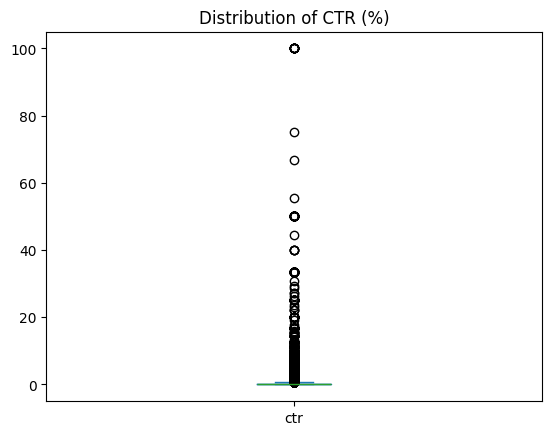

In [4]:
data["ctr"].plot(kind='box', title= 'Distribution of CTR (%)')

based on the boxplot of the CTR, most pages have very low CTR. There are also lots of outlier pages and some of them go all the way up to 100% and flagged invidiually because they fall far outside the typical range.

This confirms that the CTR is heavily right-skewed with small number of very high CTR pages pulling the average(mean) up

In [6]:
data[data["ctr"] > 90][["content_id", "ctr", "avg_position", "impressions_90d", "clicks_90d"]]

,content_id,ctr,avg_position,impressions_90d,clicks_90d
240,content_006b16e7a2e7,100.0,1.0,1,1
4606,content_3f3576c295f5,100.0,1.0,1,1
6473,content_cfa4d9f1bf0a,100.0,25.0,1,1
7514,content_b1e4f7904d85,100.0,0.0,1,1
13661,content_bf398aa7400e,100.0,2.0,1,1
18825,content_98458bafe297,100.0,1.0,1,1
19341,content_4272d3a330a3,100.0,8.0,1,1
19598,content_a84e013a5f94,100.0,9.0,1,1
21147,content_6016b918a48f,100.0,30.0,1,1
22607,content_bc2c0c7243df,100.0,1.0,1,1


I also take a closer look at the most extreme outliers which is CTR = 100% which showing all 11 of them come from just 1 impression and 1 click. I can conclude that they are small-sample noise.

Based on that finding, I will use the median instead of the mean so the outliers don't distort what a typical page looks like. I also will aply minimum-impressions filter before comparing buckets so that 1-click pages aren't sitting on the same bucket as pages with real traffic

In [7]:
for threshold in [10, 30, 50, 100, 250, 500]:
    n_rows = (data["impressions_90d"] >= threshold).sum()
    pct = n_rows / len(data) * 100
    print(f"impressions_90d >= {threshold}: {n_rows} rows kept ({pct:.1f}%)")

impressions_90d >= 10: 26254 rows kept (87.5%)
impressions_90d >= 30: 24470 rows kept (81.6%)
impressions_90d >= 50: 23521 rows kept (78.4%)
impressions_90d >= 100: 22006 rows kept (73.4%)
impressions_90d >= 250: 19386 rows kept (64.6%)
impressions_90d >= 500: 16726 rows kept (55.8%)


In [8]:
# Check how many rows are STILL in the noisy small-sample zone at your candidate threshold
low_vol = data[(data["impressions_90d"] >= 5) & (data["impressions_90d"] < 30)]
print(f"Rows with 5-29 impressions: {len(low_vol)}")
print(low_vol["ctr"].describe())

Rows with 5-29 impressions: 2750
count    2750.000000
mean        1.309305
std         4.355625
min         0.000000
25%         0.000000
50%         0.000000
75%         0.000000
max        55.560000
Name: ctr, dtype: float64


In [11]:
# Check how many rows are STILL in the noisy small-sample zone at your candidate threshold
low_vol = data[(data["impressions_90d"] >= 30) & (data["impressions_90d"] < 50)]
print(f"Rows with 30-49 impressions: {len(low_vol)}")
print(low_vol["ctr"].describe())

Rows with 30-49 impressions: 949
count    949.000000
mean       0.623235
std        2.263478
min        0.000000
25%        0.000000
50%        0.000000
75%        0.000000
max       29.410000
Name: ctr, dtype: float64


In [14]:
mid = data[(data["impressions_90d"] >= 50) & (data["impressions_90d"] < 100)]
print(f"Rows with 50-99 impressions: {len(mid)}")
print(mid["ctr"].describe())

Rows with 50-99 impressions: 1515
count    1515.000000
mean        0.369663
std         1.040326
min         0.000000
25%         0.000000
50%         0.000000
75%         0.000000
max        12.070000
Name: ctr, dtype: float64


In [13]:
# Check how many rows are STILL in the noisy small-sample zone at your candidate threshold
low_vol = data[(data["impressions_90d"] >= 100) & (data["impressions_90d"] < 250)]
print(f"Rows with 100-249 impressions: {len(low_vol)}")
print(low_vol["ctr"].describe())

Rows with 100-249 impressions: 2620
count    2620.000000
mean        0.287187
std         0.752270
min         0.000000
25%         0.000000
50%         0.000000
75%         0.440000
max        11.760000
Name: ctr, dtype: float64


**Minimum-impressions threshold: `impressions_90d >= 50`.**

I checked how CTR's spread (std) and max value changed across impression ranges just above several candidate thresholds:

| Range | std | max CTR |
|---|---|---|
| 5-29 impressions | 4.36 | 55.6% |
| 30-49 impressions | 2.26 | 29.4% |
| 50-99 impressions | 1.04 | 12.1% |
| 100-249 impressions | 0.75 | 11.8% |

The biggest drop in noise happens crossing into 50+ impressions — std more than halves again (2.26 → 1.04) and max CTR falls sharply (29.4% → 12.1%). Going further to `>= 100` barely improves things further (std 1.04 → 0.75, max nearly unchanged), while costing more data (78.4% of rows retained at `>= 50` vs. 73.4% at `>= 100`). So `>= 50` captures most of the stability benefit while keeping more of the dataset — including the 11 pages with 1 impression / 1 click = 100% CTR, which this threshold correctly excludes.

## 3. Success metric

**How I'll check if a signal matters: compare group medians, not correlation or raw averages.**

For each candidate signal (`position_tier`, `content_type`, `freshness_tier`, `word_count_tier`, `age_tier`, `main_intent`), I group the data by that signal and compare CTR across groups. If CTR differs a lot from group to group, that signal is worth reporting as associated with CTR.

I'm not using plain correlation (Pearson's r) as my main tool, because it only catches straight-line relationships. My position_tier vs CTR check proved this: the correlation was basically 0 (r = -0.073) on week 1 assignment, but grouping by tier showed a clear, obvious pattern. So correlation is just a backup check, not the main method.

I'm also not using the mean within each group because there are lots of outliers and CTR is heavily right-skewed. So I use the **median** per group instead, after applying a minimum-impressions filter (`impressions_90d >= 50`, chosen by checking where CTR's spread stabilized across impression ranges) to remove small-sample noise before comparing groups at all.

**Applying it:** using the `impressions_90d >= 50` filter and median established above, I compare CTR across buckets for each of the six candidate signals. For each signal, I calculate the spread between the highest and lowest bucket median — a large spread means that signal is worth reporting as associated with CTR; a small spread means it likely isn't. I also check the group sizes for each bucket, since a median from very few rows isn't trustworthy even after filtering.

Later, I'll run a real statistical test (like ANOVA or Kruskal-Wallis, since I'm comparing medians/means across groups) to confirm which group differences are meaningful — but not this week.

In [15]:
# Apply the minimum-impressions filter established above
filtered = data[data["impressions_90d"] >= 50]

print(f"Rows before filter: {len(data)}")
print(f"Rows after filter:  {len(filtered)} ({len(filtered)/len(data)*100:.1f}%)")

candidate_signals = ["position_tier", "content_type", "freshness_tier",
                      "word_count_tier", "age_tier", "main_intent"]

for col in candidate_signals:
    medians = filtered.groupby(col)["ctr"].median().sort_values(ascending=False)
    spread = medians.max() - medians.min()
    n_per_group = filtered.groupby(col).size()
    print(f"\n{col} (spread = {spread:.3f}):")
    print(medians)
    print("group sizes:")
    print(n_per_group)

Rows before filter: 30000
Rows after filter:  23521 (78.4%)

position_tier (spread = 0.220):
position_tier
page_1      0.22
top_3       0.18
striking    0.14
page_3_5    0.05
deep        0.00
Name: ctr, dtype: float64
group sizes:
position_tier
deep        1017
page_1      9232
page_3_5    6427
striking    6285
top_3        560
dtype: int64

content_type (spread = 0.180):
content_type
feedly article        0.18
keyword article       0.14
comparison article    0.00
Name: ctr, dtype: float64
group sizes:
content_type
comparison article      530
feedly article          466
keyword article       22525
dtype: int64

freshness_tier (spread = 0.140):
freshness_tier
0-30      0.14
91-180    0.13
181+      0.00
31-90     0.00
Name: ctr, dtype: float64
group sizes:
freshness_tier
0-30      14950
181+         52
31-90       163
91-180     8356
dtype: int64

word_count_tier (spread = 1.560):
word_count_tier
<1000        1.65
2000-3500    0.19
3500+        0.13
1000-2000    0.09
Name: ctr, dtype: f

**Reading the results: spread alone isn't enough — group size matters.**

Several signals showed a large raw spread, but checking group sizes revealed some of those spreads were driven by thin groups (a handful of rows), not a real pattern:

- **`position_tier` — real signal.** Spread of 0.22 holds up across well-populated groups (560-9,232 rows each); dropping the smallest group (`top_3`, n=560) doesn't change the pattern. CTR clearly steps down from top_3 → page_1 → striking → page_3_5 → deep.
- **`age_tier` and `main_intent` — real but weaker than they first appear.** Both show spreads that shrink noticeably once their thinnest group is set aside (age_tier: 0.20 → 0.05; main_intent: 0.07 → 0.05) — some signal remains, but it's modest, not dramatic.
- **`word_count_tier`, `freshness_tier`, `content_type` — not trustworthy as reported.** Each showed a large headline spread that almost entirely evaporates once thin groups are excluded (word_count_tier: 1.56 → 0.10; freshness_tier: 0.14 → 0.01; content_type has only one well-populated category — `keyword article` at 22,525 rows — with the other two too thin to compare against it meaningfully).

**Takeaway:** of the six candidate signals tested, `position_tier` is the one clear, well-supported signal associated with CTR at this stage. `age_tier` and `main_intent` show weak but plausible signal worth a second look with a larger sample (e.g. the warehouse release). The rest don't show enough evidence to report as real, given how thin their driving groups are.

## 4. The unit of analysis, as a real dataframe


**One row = one content item (a page)**, summarized over its trailing 90-day window. `content_id` is a join/grouping key only — never a feature, per the data dictionary's warning that IDs are pseudonyms.

Because this is a 90-day summary, I can't see whether a page's CTR or position changed *within* that window — only the average. The warehouse's daily fact table would show day-to-day movement, but that's out of scope this week.

One more limit worth naming here: my Section 3 analysis only uses the filtered subset (`impressions_90d >= 50`, 78.4% of rows) — so "one row = one page" is technically true for the full dataset, but my actual findings describe pages with at least moderate traffic, not every page in the starter CSV.

In [16]:
# Verify the grain claim, don't just assert it
print("Total rows:", len(data))
print("Unique content_id:", data["content_id"].nunique())
assert len(data) == data["content_id"].nunique(), "content_id is not unique — grain assumption is wrong!"

# Show the unit of analysis as an actual dataframe
data[["content_id", "client_id", "ctr", "position_tier", "impressions_90d"]].head(10)

Total rows: 30000
Unique content_id: 30000


,content_id,client_id,ctr,position_tier,impressions_90d
0,content_304f48230142,client_f369cb89fc,0.76,striking,3803
1,content_a1fb4e703a9e,client_4e07408562,0.05,page_3_5,15320
2,content_9aa793d4d895,client_7f2253d7e2,0.09,page_3_5,12581
3,content_331d6c4de07b,client_19581e27de,0.49,page_1,11751
4,content_d99b7a2d90ca,client_3fdba35f04,0.13,page_3_5,19140
5,content_d4084a4bc775,client_f369cb89fc,0.03,page_1,3970
6,content_9a34b442b552,client_8722616204,0.00,page_1,20
7,content_a63219c6e95a,client_19581e27de,0.06,page_3_5,1724
8,content_5e6c160719bc,client_6208ef0f77,0.09,page_3_5,32574
9,content_c27558df2b0c,client_19581e27de,0.16,page_1,1240


## 5. Why ML beats a fixed rule here

**Right now, it doesn't**

This week is EDA and grouped statistics on purpose: Lane 1 exists to find out *which* signals are worth building something more sophisticated around, before committing to a model. A plain rule (median bucket comparison) is the right tool here because I'm not yet combining multiple weak signals into one decision — and the process paid off: it caught two headline-looking spreads (`word_count_tier`, `freshness_tier`) that turned out to be artifacts of thin groups, not real signal, before I could overclaim them.

**Where this leads:** the one signal that survived scrutiny — `position_tier` — showed a real, well-supported pattern: CTR steps down consistently from top_3 → page_1 → striking → page_3_5 → deep, across well-populated groups. This is the exact pattern Lane 4 (CTR / Engagement Opportunity Scoring) formalizes as "expected CTR by position tier" — computing each page's expected CTR for its tier, then flagging pages that fall well below that expectation as review candidates. That's where a real model (logistic regression or a tree) will earn its place: once I've confirmed which signals reliably move CTR — position_tier being the clearest so far — a model can combine several such signals into one ranked priority score, something a human can't hand-weight as reliably as a trained model, one signal at a time.

## Self-check

Before you submit, confirm each line honestly:

- [Done] Every section above is filled — markdown thinking AND the code that backs it
- [Done] The notebook runs top to bottom with no errors (Runtime → Run all)
- [Done] No client names, URLs, or private queries anywhere
- [Done] My claims use careful words: observed, measured, directional, decision-support
- [Done] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.